In [1]:
# !pip install ncmcm

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
from ncmcm.cognitive_graphs.cognitive_graphs import behavioral_state_diagram
from sklearn.ensemble import RandomForestClassifier
from ncmcm.cognitive_graphs.cognitive_graphs import cluster_neural_activity
from ncmcm.statistical_testing.markov import *
from IPython.display import HTML
import os

In [3]:
os.getcwd()
os.chdir('..')

## Load Data (excluding behavioural neurons)

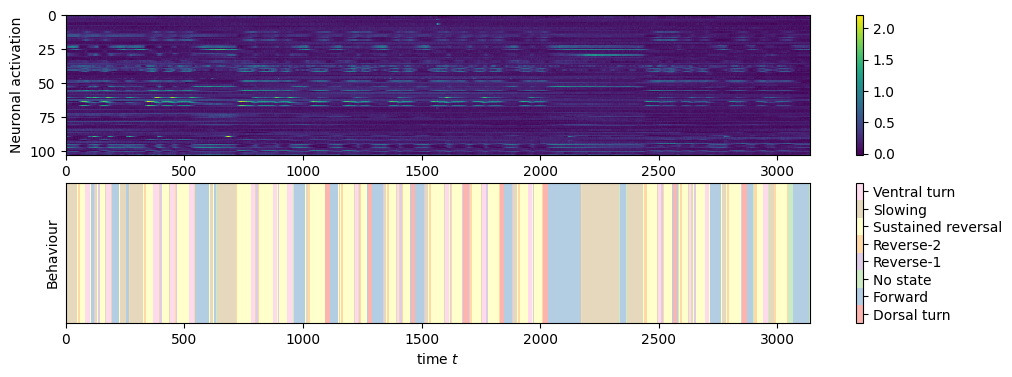

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: xlabel='time $t$', ylabel='Neuronal activation'>,
        <Axes: xlabel='time $t$', ylabel='Behaviour'>], dtype=object))

In [4]:
worm_num = 0
b_neurons = [
    'AVAR',
    'AVAL',
    'SMDVR',
    'SMDVL',
    'SMDDR',
    'SMDDL',
    'RIBR',
    'RIBL'
]
data_path = 'datasets/raw/c_elegans/NoStim_Data.mat'
data = Database(data_path=data_path, dataset_no=worm_num)
data.exclude_neurons(b_neurons)
x = data.neuron_traces.T
b = data.behaviour
behaviors = list(data.behaviour_names.values())

plotting_neuronal_behavioural(x, b, b_names=data.behaviour_names)

## Cognitive state sequence by clustering behavioral probability trajectories (BPT)

In [5]:
# This method allows for a lot of customisability, with only the first 3 parameters being required
# For the model parameter each classifier with the methods: predict, predict_proba and fit works fine
cognitive_states = cluster_neural_activity(N=x.T, 
                                           B=b.astype(int),
                                           n_clusters=3,
                                           nrep=5,
                                           ensemble=True,
                                           sim_m=500,
                                           sim_s=500,
                                           chunks=0,
                                           clustering='kmeans',
                                           kmeans_init='auto',
                                           stationary=True,
                                           model=RandomForestClassifier(n_estimators=20, # we use a RandomForest
                                                                        random_state=42))
# Use the cognitive state sequence with the best p-values.
# The 'nrep's are sorted by p-value. P-values signaling a markov process are first.
# Each tuple in the list contains: 
# - the sequence;
# - p-value markov property;
# - p-value stationary property (optional);

best_result = cognitive_states[0]
best_sequence = best_result[0]

Accuracy for full training data: 0.9993624481989162
Testing markovianity for 3 clusters - repetition 1
Testing markovianity for 3 clusters - repetition 2
Testing markovianity for 3 clusters - repetition 3
Testing markovianity for 3 clusters - repetition 4
Testing markovianity for 3 clusters - repetition 5


## Plot the cognitive graph

['Dorsal turn', 'Forward', 'No state', 'Reverse-1', 'Reverse-2', 'Sustained reversal', 'Slowing', 'Ventral turn']


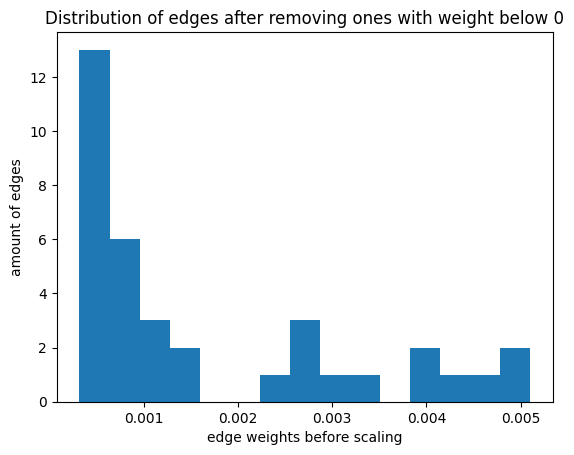

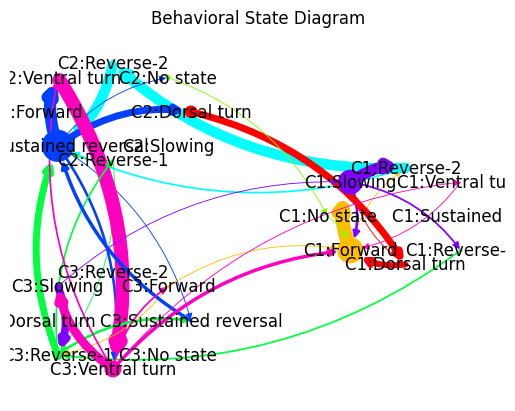

In [5]:
# First we plot the diagram with all edges by setting threshold to 0. Using the weight_hist we see 
# the distribution in edge thickness
result = behavioral_state_diagram(best_sequence, b, behaviors=behaviors,
                                  weights_hist=True,
                                  bins=15,
                                  threshold=0)

['Dorsal turn', 'Forward', 'No state', 'Reverse-1', 'Reverse-2', 'Sustained reversal', 'Slowing', 'Ventral turn']


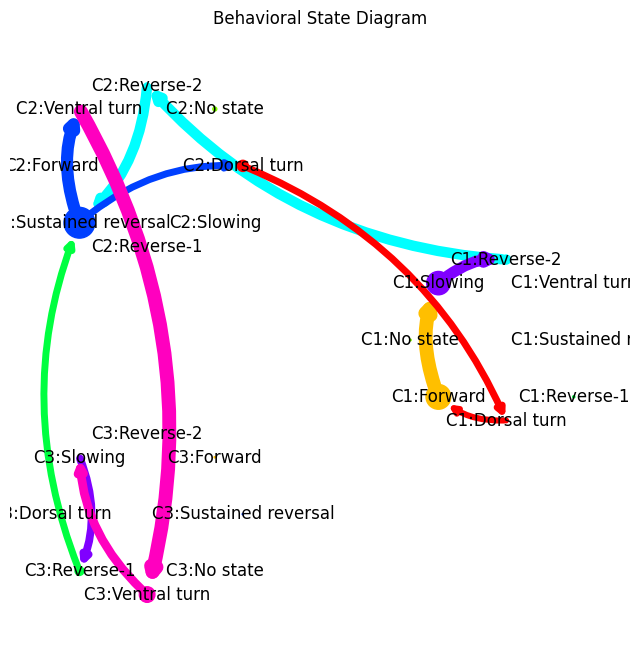

['Dorsal turn', 'Forward', 'No state', 'Reverse-1', 'Reverse-2', 'Sustained reversal', 'Slowing', 'Ventral turn']
Calculated threshold is:  0.000510204081632653


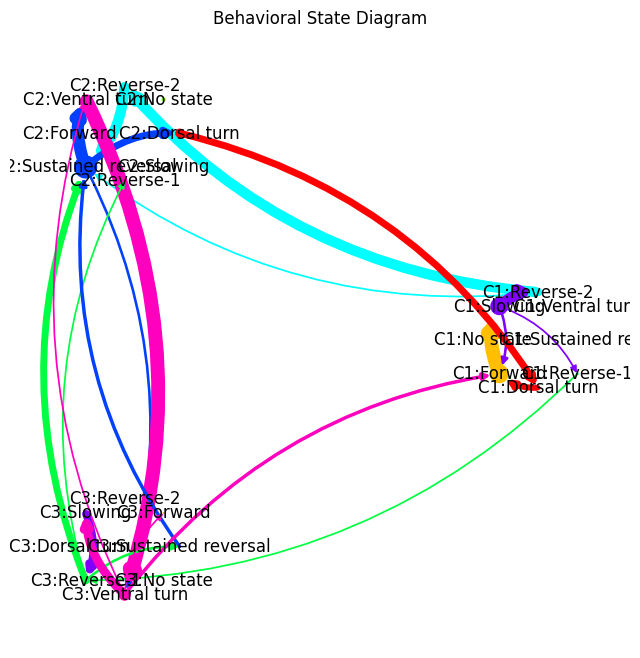

True

In [6]:
# Using these insights we can either let the algorithm decide where to put the cut-off or decide our self.
# We can also define a offset, this will change the spacing between clusters.
behavioral_state_diagram(best_sequence, b,
                         behaviors=behaviors,
                         threshold=0.002,
                         figsize=(8, 8))
behavioral_state_diagram(best_sequence, b,
                         behaviors=behaviors,
                         offset=5,
                         figsize=(8, 8))

['Dorsal turn', 'Forward', 'No state', 'Reverse-1', 'Reverse-2', 'Sustained reversal', 'Slowing', 'Ventral turn']
Calculated threshold is:  0.000510204081632653


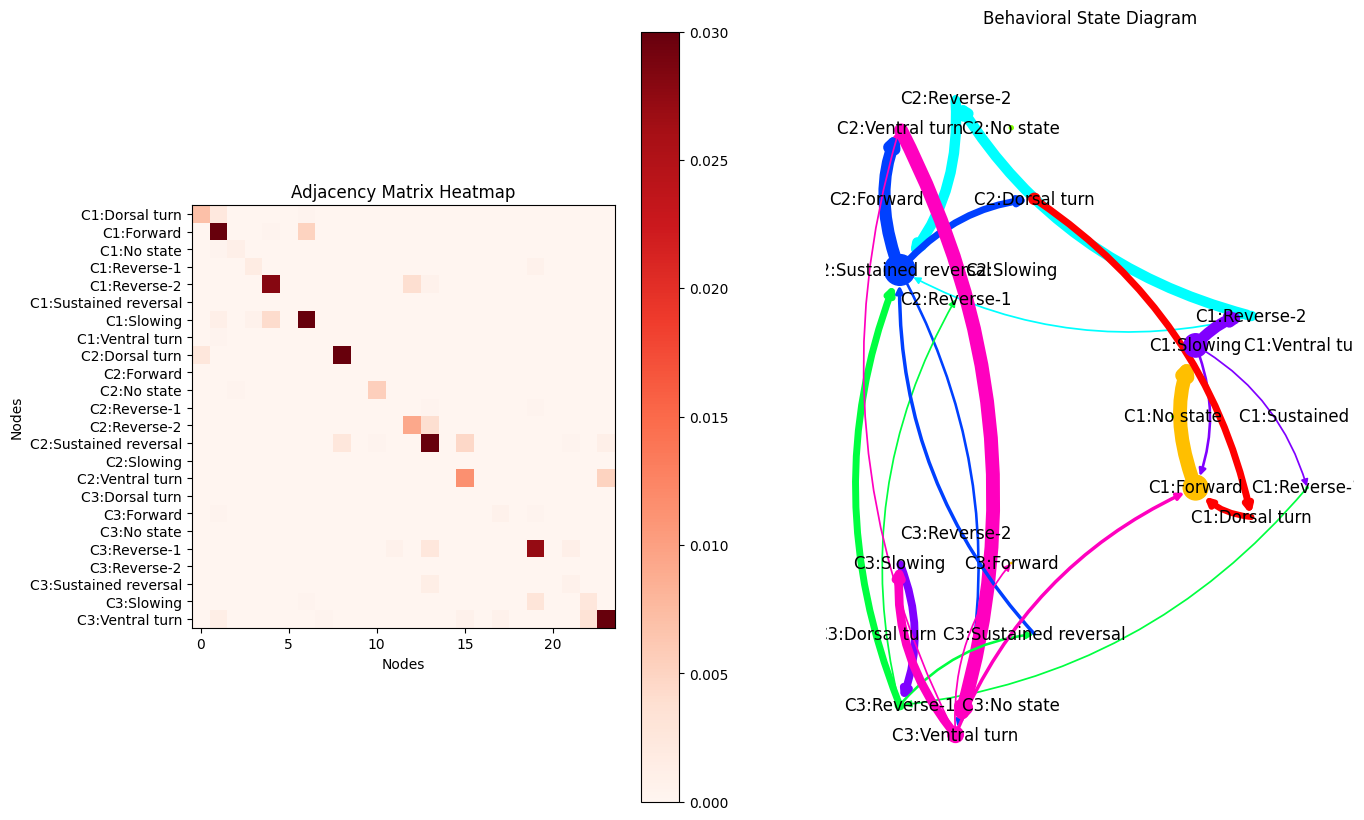

True

In [7]:
# Next we also plot the adjacency matrix
behavioral_state_diagram(best_sequence, b,
                         behaviors=behaviors,
                         adj_matrix=True,
                         figsize=(15, 10))

## Interactive plots (using pyvis)

In [6]:
# For the interactive graph we set a filename were we want to save the HTML-file and we can also set an option parameter. This is set with a predefined physics script [options = 0, 1 or 2] or a custom script with a path to the JSON-file. The default value for options is 0, giving a graph with forces pushing nodes apart and pulling edges together. 
behavioral_state_diagram(best_sequence, b,
                         behaviors=behaviors,
                         interactive='figures/Interactive_graph',
                         options=0)

behavioral_state_diagram(best_sequence, b,
                         behaviors=behaviors,
                         interactive='figures/Interactive_graph_no_physics',
                         options='ncmcm/cognitive_graphs/json_physics/custom_physics.json')

Calculated threshold is:  0.000510204081632653
figures/Interactive_graph.html
Plot has been saved under: figures/Interactive_graph.html
Calculated threshold is:  0.000510204081632653
figures/Interactive_graph_no_physics.html
Plot has been saved under: figures/Interactive_graph_no_physics.html


True

# Interactive Plot 
- We used the Interactive_graph_no_physics.html file
- We display screenshots of the HTML-file, however accessing the files with a browser allows for a better user-experience

Below one can see three pictures of the interactive plots. In the first two images a node ("C2:Slowing" or "C2:Forward") has been selected using the select-menu at the top. This will only display nodes directly connected to it and their connections. The rest of the edges and nodes and there connections are greyed out.

In the third image we used the filter-menu directly below the select-menu to only show cognitive states 1 and 2. Using this we can display certain aspects of the plot in more detail.
<p>&nbsp;</p>
<img src="../figures/Interactive_selection.png" width="1600" alt="Interactive plot with a node selected.">
<img src="../figures/Interactive_selection_hover.png" width="1600" alt="Interactive plot with a node selected.">
<img src="../figures/Interactive_selection_C1_C2.png" width="1600" alt="Interactive plot with a certain clusters displayed.">



## Statistical tests

In [ ]:
# Simulate some sequences
seq_1, _ = simulate_markovian(M=1000, N=5, order=1)
seq_2, _ = simulate_markovian(M=1000, N=5, order=2)
seq_non_stat = non_stationary_process(M=1000, N=5)

In [11]:
# The markov property test returns the empirical 1st order transition matrix and a p-value.
# A p-value below 0.05 signals behavior not agreeable with a 1st order markov process.
p_1, P_1 = markovian(seq_1)
p_2, P_2 = markovian(seq_2)
print(f'Since {round(p_1, 3)} > 0.05, the sequence could come from a 1st order Markov process')
print(f'Since {round(p_2, 3)} < 0.05, the sequence seems not to come from a 1st order Markov process')

Since 0.981 > 0.05, the sequence could come from a 1st order Markov process
Since 0.0 < 0.05, the sequence seems not to come from a 1st order Markov process


In [14]:
# The stationary property test returns the adjusted p-value and the unadjusted p-value.
# A adjusted p-value below 0.05 signals behavior agreeable with a stationary markov process.
p_adjusted_1, p_unadjusted_1 = stationarity(seq_1, chunks=None)
p_adjusted_non_stat, p_unadjusted_non_stat = stationarity(seq_non_stat, chunks=5)
print(f'Since {round(p_adjusted_1, 3)} < 0.05, the sequence could come from a Markov process')
print(f'Since {round(p_adjusted_non_stat, 3)} > 0.05, the sequence seems not to come from a stationary Markov process')

Since 0.02 < 0.05, the sequence could come from a Markov process
Since 0.606 > 0.05, the sequence seems not to come from a stationary Markov process
